<a href="https://colab.research.google.com/github/ankit-rathi/quantvesting_v3/blob/main/notebooks/06_QUANTVESTING_SIP_MULTI_STRATEGY_BACKTEST_RISK_CONSTRAINED_INTEGER_SHARES_EQUAL_CASH_REDEPLOYMENT_APPLE_TO_APPLE_FINAL_LATEST_NIFTY50_TOP20_TOP30_EXIT_AFTER_TAX_COSTS.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Quantvesting — Unified 07–14 Apple-to-Apple Multi-Strategy Backtest — After-Tax / All-Costs Edition

This notebook is a consolidated comparison engine built from the supplied **06_QUANTVESTING...APPLE_TO_APPLE_FINAL (1)** baseline and the finalized strategy definitions used in standalone notebooks **07 through 14**.

## Strategies included

1. **07 — ATH Drawdown + Recovery**
2. **08 — Risk-Constrained Original Quantvesting**
3. **09 — 200-DMA Drawdown Top-N**
4. **10 — ATH Drawdown Top-N**
5. **11 — ATH + 200-DMA Composite Top-N**
6. **12 — Trend-Confirmed Pullback Top-N**
7. **13 — Regime-Adaptive Quantvesting**
8. **14 — Relative Strength + Pullback Top-N**
9. **Nifty 50 SIP — Price Index Baseline**

The objective is to change the **selection / exit rule**, while holding the portfolio implementation, capital schedule, transaction assumptions, integer-share mechanics, position risk, sector purchase cap, cash policy, accounting and comparison outputs constant.

> **Important:** This is a historical research comparison, not a forecast. Run top-to-bottom in a fresh runtime. The notebook downloads the same market universe from `sample_data/signals.csv` and uses point-in-time signals with next-trading-day execution.
This version preserves the existing strategy-selection and portfolio rules, but now accounts for transaction costs on BUY/TRIM/SELL events and realized capital-gains tax on profitable sales using the requested Indian equity rates: **20% STCG for holdings sold within 12 months and 12.5% LTCG after 12 months**. Tax is paid from portfolio cash, so the reported corpus and XIRR are after modeled tax and trading costs.


In [1]:
# 1. Dependencies
from pathlib import Path
import math, re, hashlib, warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import yfinance as yf
from IPython.display import display
warnings.filterwarnings("ignore")

In [2]:
# 2. COMMON CONFIGURATION — intentionally aligned with finalized standalone 07–14 notebooks
SIGNAL_FILE = Path("sample_data/signals.csv")
START_DATE = "2016-10-01"
END_DATE = "2026-09-30"
EXPECTED_MONTHS = None
INITIAL_LUMP_SUM = 0
MONTHLY_SIP = 100_000
SIP_IN_FIRST_MONTH = True

TOP_N = 20
TOP_EXIT_N = 30
MAX_HOLDINGS = 30
MAX_POSITION_PCT = 0.05
POSITION_REVIEW_PCT = 0.08
POSITION_HARD_PCT = 0.10
POSITION_TRIM_TARGET_PCT = 0.08
MAX_SECTOR_PCT = 0.20
TRANSACTION_COST_BPS = 10
SLIPPAGE_BPS = 5

# Realized capital-gains tax model (requested simplified Indian equity model)
STCG_TAX_RATE = 0.20
LTCG_TAX_RATE = 0.125
TAX_INCLUDE_CESS = False        # False keeps the requested 20% / 12.5% headline rates
HISTORY_PERIOD = "max"
ALLOW_REPEAT_BUYS = True
TARGET_CASH_BUFFER_PCT = 0.05
AS_OF_DATE = None

# Strategy-specific fixed research specifications
ATH_DRAWDOWN_MIN = 0.20
DMA_WINDOW = 200

FAST_DMA_WINDOW = 50
SLOW_DMA_WINDOW = 200
TREND_SLOPE_LOOKBACK = 50
PULLBACK_LOOKBACK = 252
MIN_PULLBACK = 0.10

RISK_ON_BREADTH_MIN = 0.60
RISK_OFF_BREADTH_MAX = 0.40
RISK_ON_WEIGHTS = (0.20, 0.20, 0.20, 0.40)
NEUTRAL_WEIGHTS = (0.25, 0.25, 0.25, 0.25)
RISK_OFF_WEIGHTS = (0.30, 0.30, 0.25, 0.15)

RS_6M_WINDOW = 126
RS_12M_WINDOW = 252
RS_SKIP_DAYS = 21
RS_WEIGHTS = (0.30, 0.30, 0.40)  # 6M RS, 12M RS, pullback

STRATEGIES = [
    "07 — ATH Drawdown + Recovery",
    "08 — Risk-Constrained Original Quantvesting",
    "09 — 200-DMA Drawdown Top-N",
    "10 — ATH Drawdown Top-N",
    "11 — ATH + 200-DMA Composite Top-N",
    "12 — Trend-Confirmed Pullback Top-N",
    "13 — Regime-Adaptive Quantvesting",
    "14 — Relative Strength + Pullback Top-N",
]

COST_RATE = TRANSACTION_COST_BPS / 10_000
SLIP_RATE = SLIPPAGE_BPS / 10_000

In [3]:
# 3. Configuration validation
if not SIGNAL_FILE.exists():
    raise FileNotFoundError(f"Signal file not found: {SIGNAL_FILE.resolve()}")
if pd.Timestamp(END_DATE) < pd.Timestamp(START_DATE): raise ValueError("END_DATE before START_DATE")
if MIN_PULLBACK <= 0 or MIN_PULLBACK >= 1: raise ValueError("MIN_PULLBACK must be between 0 and 1")
if MAX_HOLDINGS <= 0 or TOP_N <= 0 or TOP_EXIT_N < TOP_N: raise ValueError("TOP_N/MAX_HOLDINGS/TOP_EXIT_N invalid")
if MAX_POSITION_PCT <= 0 or MAX_POSITION_PCT > 1: raise ValueError("Invalid position cap")
if POSITION_TRIM_TARGET_PCT > POSITION_HARD_PCT: raise ValueError("Trim target must not exceed hard threshold")
if MAX_SECTOR_PCT <= 0 or MAX_SECTOR_PCT > 1: raise ValueError("Invalid sector cap")
if RS_6M_WINDOW >= RS_12M_WINDOW or RS_SKIP_DAYS >= RS_6M_WINDOW: raise ValueError("Invalid RS windows")
if not (0 < RISK_OFF_BREADTH_MAX < RISK_ON_BREADTH_MIN < 1): raise ValueError("Invalid regime thresholds")
print("Configuration validated")
print(f"Journey: {START_DATE} → {END_DATE}")
print(f"Monthly SIP: ₹{MONTHLY_SIP:,.0f} | Initial lump sum: ₹{INITIAL_LUMP_SUM:,.0f}")
print(f"Common portfolio: {MAX_HOLDINGS} holdings | {MAX_POSITION_PCT:.0%} purchase cap | {MAX_SECTOR_PCT:.0%} sector purchase cap | {TARGET_CASH_BUFFER_PCT:.0%} cash target")
if not (0 <= STCG_TAX_RATE <= 1 and 0 <= LTCG_TAX_RATE <= 1): raise ValueError("Invalid capital-gains tax rates")
print(f"Tax model: STCG {STCG_TAX_RATE:.1%} | LTCG {LTCG_TAX_RATE:.1%} | Cess included: {TAX_INCLUDE_CESS}")


Configuration validated
Journey: 2016-10-01 → 2026-09-30
Monthly SIP: ₹100,000 | Initial lump sum: ₹0
Common portfolio: 30 holdings | 5% purchase cap | 20% sector purchase cap | 5% cash target
Tax model: STCG 20.0% | LTCG 12.5% | Cess included: False


In [4]:
# 4. Load and validate the common signal universe
signals_config = pd.read_csv(SIGNAL_FILE)
signals_config.columns = [str(c).strip().lower() for c in signals_config.columns]
required = {"symbol", "conviction", "category"}
missing = required - set(signals_config.columns)
if missing: raise ValueError(f"signals.csv missing columns: {sorted(missing)}")
signals_config["symbol"] = signals_config["symbol"].astype(str).str.strip().str.upper()
signals_config["conviction"] = signals_config["conviction"].astype(str).str.strip().str.upper()
signals_config["category"] = signals_config["category"].astype(str).str.strip().replace({"": "Unknown"})
if signals_config["symbol"].duplicated().any(): raise ValueError("Duplicate symbols in signals.csv")
signals_config = signals_config[signals_config["conviction"].isin(["X-LC","H-LC"])].copy()
signals_config = signals_config[signals_config["symbol"] != "LTIM"].reset_index(drop=True)
signals_config["conviction_rank"] = signals_config["conviction"].map({"X-LC":1,"H-LC":2})
CATEGORY_MAP = dict(zip(signals_config["symbol"], signals_config["category"]))
YF_TICKERS = {f"{s}.NS":s for s in signals_config["symbol"]}
if len(signals_config) < MAX_HOLDINGS: raise ValueError("Universe is smaller than MAX_HOLDINGS")
print(f"Universe: {len(signals_config)} stocks")
display(signals_config.head(20).style.hide(axis="index"))

Universe: 53 stocks


symbol,conviction,category,conviction_rank
TMPV,X-LC,AUTO,1
TCS,X-LC,IT,1
ITC,X-LC,FMCG,1
INFY,X-LC,IT,1
JIOFIN,X-LC,FINANCE,1
VBL,X-LC,FMCG,1
BAJAJFINSV,X-LC,FINANCE,1
LTM,H-LC,IT,2
DLF,H-LC,REALTY,2
HDFCLIFE,X-LC,INSURANCE,1


In [5]:
# 5. Download the common daily market dataset once for every strategy
market_download_end = (pd.Timestamp(END_DATE) + pd.Timedelta(days=2)).strftime("%Y-%m-%d")
def yf_download(tickers, start=None, end=None, period=None):
    kwargs = dict(tickers=tickers, interval="1d", auto_adjust=False, actions=False, progress=False, repair=True, group_by="column")
    if period is not None: kwargs["period"] = period
    else: kwargs.update(start=start, end=end)
    return yf.download(**kwargs)
raw = yf_download(list(YF_TICKERS.keys()), period=HISTORY_PERIOD)
rows=[]
if isinstance(raw.columns, pd.MultiIndex):
    fields=set(raw.columns.get_level_values(0))
    for field in ["Open","High","Low","Close"]:
        if field not in fields: continue
        block=raw[field]
        if isinstance(block,pd.Series): block=block.to_frame()
        for ticker in block.columns:
            sym=YF_TICKERS.get(str(ticker),str(ticker).replace(".NS",""))
            s=pd.to_numeric(block[ticker],errors="coerce")
            for d,v in s.dropna().items(): rows.append((pd.Timestamp(d).tz_localize(None),sym,field,float(v)))
else:
    ticker=list(YF_TICKERS.keys())[0]; sym=YF_TICKERS[ticker]
    for field in ["Open","High","Low","Close"]:
        if field in raw.columns:
            s=pd.to_numeric(raw[field],errors="coerce")
            for d,v in s.dropna().items(): rows.append((pd.Timestamp(d).tz_localize(None),sym,field,float(v)))
long=pd.DataFrame(rows,columns=["date","symbol","field","value"])
if long.empty: raise RuntimeError("No market data downloaded")
prices=long.pivot_table(index=["date","symbol"],columns="field",values="value",aggfunc="last").reset_index()
prices=prices.sort_values(["symbol","date"]).reset_index(drop=True)
prices=prices[prices["date"]<=pd.Timestamp(END_DATE)].copy()
print(f"Downloaded {len(prices):,} daily rows across {prices['symbol'].nunique()} stocks")
print(f"Data: {prices['date'].min():%d %b %Y} → {prices['date'].max():%d %b %Y}")

ERROR:yfinance:
1 Failed download:
ERROR:yfinance:['PIDILITIND.NS']: IntCastingNaNError('Cannot convert non-finite values (NA or inf) to integer')


Downloaded 293,339 daily rows across 52 stocks
Data: 02 Jan 1991 → 24 Sep 2026


In [6]:
# 6. Point-in-time common and strategy-specific indicators
p=prices.copy()
p["conviction"]=p["symbol"].map(dict(zip(signals_config.symbol,signals_config.conviction)))
p["conviction_rank"]=p["symbol"].map(dict(zip(signals_config.symbol,signals_config.conviction_rank)))
p["category"]=p["symbol"].map(CATEGORY_MAP)
p["running_ath"]=p.groupby("symbol")["Close"].cummax()
p["ath_gap"]=(p["running_ath"]-p["Close"])/p["Close"]
p["ath_drawdown"]=p["Close"]/p["running_ath"]-1
p["dma_200"]=p.groupby("symbol")["Close"].transform(lambda s:s.rolling(200,min_periods=200).mean())
p["dma_gap"]=(p["dma_200"]-p["Close"])/p["Close"]
p["above_dma200"]=p["Close"]>=p["dma_200"]
p["dma_50"]=p.groupby("symbol")["Close"].transform(lambda s:s.rolling(50,min_periods=50).mean())
p["dma_200_slope_base"]=p.groupby("symbol")["dma_200"].shift(TREND_SLOPE_LOOKBACK)
p["trend_distance"]=p["Close"]/p["dma_200"]-1
p["trend_alignment"]=p["dma_50"]/p["dma_200"]-1
p["trend_slope"]=p["dma_200"]/p["dma_200_slope_base"]-1
p["trailing_high"]=p.groupby("symbol")["Close"].transform(lambda s:s.rolling(PULLBACK_LOOKBACK,min_periods=PULLBACK_LOOKBACK).max())
p["pullback"]=1-p["Close"]/p["trailing_high"]
p["trend_confirmed"]=(p["Close"]>p["dma_200"])&(p["dma_50"]>p["dma_200"])&(p["trend_slope"]>0)
p["rs_6m"]=p.groupby("symbol")["Close"].transform(lambda s:s.shift(RS_SKIP_DAYS)/s.shift(RS_6M_WINDOW+RS_SKIP_DAYS)-1)
p["rs_12m"]=p.groupby("symbol")["Close"].transform(lambda s:s.shift(RS_SKIP_DAYS)/s.shift(RS_12M_WINDOW+RS_SKIP_DAYS)-1)
# Point-in-time regime from the same universe
p["breadth_200dma"]=p.groupby("date")["trend_distance"].transform(lambda x: float((x.dropna()>0).mean()) if len(x.dropna()) else np.nan)
p["median_trend_slope"]=p.groupby("date")["trend_slope"].transform("median")
p["market_regime"]=np.select([(p["breadth_200dma"]>=RISK_ON_BREADTH_MIN)&(p["median_trend_slope"]>0),(p["breadth_200dma"]<=RISK_OFF_BREADTH_MAX)|(p["median_trend_slope"]<0)], ["Risk-On","Risk-Off"], default="Neutral")
prices=p

In [7]:
# 7. Common monthly contribution calendar
window=prices[(prices.date>=pd.Timestamp(START_DATE))&(prices.date<=pd.Timestamp(END_DATE))]
market_days=pd.DatetimeIndex(sorted(window.date.unique()))
month_first=pd.Series(market_days,index=market_days).groupby(market_days.to_period("M")).first()
sip_dates_all=pd.DatetimeIndex(month_first.values)
first_month=sip_dates_all[0].to_period("M")
sip_dates=pd.DatetimeIndex([d for d in sip_dates_all if SIP_IN_FIRST_MONTH or d.to_period("M")!=first_month])
INITIAL_CONTRIBUTION_DATE=pd.Timestamp(sip_dates_all[0])
SIP_SET=set(sip_dates)
print(f"Journey months: {len(sip_dates_all)}")
print(f"External contributions: ₹{INITIAL_LUMP_SUM + MONTHLY_SIP*len(sip_dates):,.0f}")

Journey months: 120
External contributions: ₹12,000,000


## 8. Strategy signal definitions and A/B experiment

The underlying BUY/screen definitions remain unchanged for 07–14. This experiment adds two portfolio-management variants for every stock strategy:

- **A — Accumulate:** monthly Top-20 opportunities are purchased using the existing common portfolio controls; there is no routine rank-based exit.
- **B — Top-30 Exit:** exactly the same Top-20 purchase logic and portfolio controls, plus a monthly exit at the next trading-day open for any existing holding that is outside the **Top 30** on the prior EOD screen.

The Nifty 50 benchmark is unchanged and appears once.


In [8]:
# 9. Candidate selector — point-in-time only

def pct_rank(s): return s.rank(method="average",pct=True)
def regime_weights(regime): return {"Risk-On":RISK_ON_WEIGHTS,"Risk-Off":RISK_OFF_WEIGHTS}.get(regime,NEUTRAL_WEIGHTS)

def candidates_on_date(signal_date, strategy, limit=TOP_N):
    d=prices[prices.date==pd.Timestamp(signal_date)].copy()
    if d.empty: return d
    d=d[d.symbol.isin(signals_config.symbol)].copy(); d["conviction_priority"]=d["conviction_rank"].fillna(99)
    if strategy.startswith("07"):
        q=d[(d.ath_gap>=ATH_DRAWDOWN_MIN)&(d.Close>=d.dma_200)].copy(); return q.sort_values(["ath_gap","conviction_priority","symbol"],ascending=[False,True,True]).head(limit).reset_index(drop=True)
    if strategy.startswith("09"):
        q=d[d.dma_gap>0].copy(); return q.sort_values(["dma_gap","conviction_priority","symbol"],ascending=[False,True,True]).head(limit).reset_index(drop=True)
    if strategy.startswith("10"):
        q=d[d.ath_gap>=ATH_DRAWDOWN_MIN].copy(); return q.sort_values(["ath_gap","conviction_priority","symbol"],ascending=[False,True,True]).head(limit).reset_index(drop=True)
    if strategy.startswith("11"):
        q=d[d.ath_gap.notna()&d.dma_gap.notna()].copy(); q["ath_rank"]=pct_rank(q.ath_gap); q["dma_rank"]=pct_rank(q.dma_gap); q["composite_score"]=0.5*q.ath_rank+0.5*q.dma_rank; return q.sort_values(["composite_score","conviction_priority","symbol"],ascending=[False,True,True]).head(limit).reset_index(drop=True)
    if strategy.startswith("12"):
        q=d[d.trend_confirmed&(d.pullback>=MIN_PULLBACK)&d[["trend_distance","trend_alignment","trend_slope","pullback"]].notna().all(axis=1)].copy()
        if q.empty:return q
        q["trend_distance_rank"]=pct_rank(q.trend_distance); q["trend_alignment_rank"]=pct_rank(q.trend_alignment); q["trend_slope_rank"]=pct_rank(q.trend_slope); q["pullback_rank"]=pct_rank(q.pullback); q["composite_score"]=0.20*q.trend_distance_rank+0.20*q.trend_alignment_rank+0.20*q.trend_slope_rank+0.40*q.pullback_rank
        return q.sort_values(["composite_score","conviction_priority","symbol"],ascending=[False,True,True]).head(limit).reset_index(drop=True)
    if strategy.startswith("13"):
        q=d[d.trend_confirmed&(d.pullback>=MIN_PULLBACK)&d[["trend_distance","trend_alignment","trend_slope","pullback"]].notna().all(axis=1)].copy()
        if q.empty:return q
        regime=str(q.market_regime.dropna().iloc[0]) if q.market_regime.notna().any() else "Neutral"; wd,wa,ws,wp=regime_weights(regime)
        q["trend_distance_rank"]=pct_rank(q.trend_distance); q["trend_alignment_rank"]=pct_rank(q.trend_alignment); q["trend_slope_rank"]=pct_rank(q.trend_slope); q["pullback_rank"]=pct_rank(q.pullback); q["composite_score"]=(wd*q.trend_distance_rank+wa*q.trend_alignment_rank+ws*q.trend_slope_rank+wp*q.pullback_rank)/(wd+wa+ws+wp); q["regime_weight_profile"]=regime
        return q.sort_values(["composite_score","conviction_priority","symbol"],ascending=[False,True,True]).head(limit).reset_index(drop=True)
    if strategy.startswith("14"):
        q=d[(d.Close>d.dma_200)&(d.pullback>=MIN_PULLBACK)&d[["rs_6m","rs_12m","pullback"]].notna().all(axis=1)].copy()
        if q.empty:return q
        q["rs_6m_rank"]=pct_rank(q.rs_6m); q["rs_12m_rank"]=pct_rank(q.rs_12m); q["pullback_rank"]=pct_rank(q.pullback); q["composite_score"]=0.30*q.rs_6m_rank+0.30*q.rs_12m_rank+0.40*q.pullback_rank
        return q.sort_values(["composite_score","conviction_priority","symbol"],ascending=[False,True,True]).head(limit).reset_index(drop=True)
    if strategy.startswith("08"):
        q=d[d.ath_gap>ATH_DRAWDOWN_MIN].copy(); return q.sort_values(["ath_gap","conviction_priority","symbol"],ascending=[False,True,True]).head(limit).reset_index(drop=True)
    raise ValueError(strategy)


In [9]:
# 10. Common portfolio accounting, execution, transaction-cost and tax helpers


def market_value(positions, last_close):
    return sum(int(v["shares"])*float(last_close[s]) for s,v in positions.items() if s in last_close and np.isfinite(last_close[s]))


def tax_rate_for_sale(acquisition_date, sale_date):
    """Requested simplified Indian equity tax split: <=12 months STCG, >12 months LTCG."""
    if pd.Timestamp(sale_date) >= pd.Timestamp(acquisition_date) + pd.DateOffset(months=12):
        return LTCG_TAX_RATE, "LTCG"
    return STCG_TAX_RATE, "STCG"


def effective_tax_rate(rate):
    return rate * (1.04 if TAX_INCLUDE_CESS else 1.0)


def consume_lots_fifo(pos, qty, sale_date, gross_proceeds, sale_cost):
    """Remove qty shares FIFO and return realized gain/tax plus detailed lot attribution.
    Acquisition transaction costs are included in lot cost basis; sale transaction costs reduce sale proceeds.
    Tax is charged only on positive realized gain under the requested simplified model.
    """
    remaining=int(qty)
    if remaining <= 0:
        return 0.0, 0.0, 0.0, []
    lots=pos.setdefault("lots", [])
    if sum(int(l["shares"]) for l in lots) < remaining:
        raise ValueError(f"FIFO lot mismatch for sale of {remaining} shares; available={sum(int(l['shares']) for l in lots)}")
    sale_cost_total=float(sale_cost)
    gross=float(gross_proceeds)
    # Allocate selling cost pro-rata to the shares sold. Since all sold shares use the same execution price,
    # this is equivalent to allocating total selling cost across sold shares.
    proceeds_after_cost=gross-sale_cost_total
    gain_total=0.0; tax_total=0.0; stcg_gain=0.0; ltcg_gain=0.0; stcg_tax=0.0; ltcg_tax=0.0; realized_cost_basis=0.0; details=[]
    sold_total=0
    while remaining>0:
        lot=lots[0]
        take=min(remaining,int(lot["shares"]))
        unit_basis=float(lot["unit_cost_basis"])
        basis=take*unit_basis
        alloc_proceeds=proceeds_after_cost*(take/qty)
        gain=alloc_proceeds-basis
        rate,term=tax_rate_for_sale(lot["buy_date"],sale_date)
        taxable=max(0.0,gain)
        tax=taxable*effective_tax_rate(rate)
        gain_total += gain; tax_total += tax; realized_cost_basis += basis
        if term == "STCG": stcg_gain += gain; stcg_tax += tax
        else: ltcg_gain += gain; ltcg_tax += tax
        details.append({"buy_date":pd.Timestamp(lot["buy_date"]),"sell_date":pd.Timestamp(sale_date),"shares":take,"unit_cost_basis":unit_basis,"cost_basis":basis,"net_sale_proceeds":alloc_proceeds,"realized_gain":gain,"taxable_gain":taxable,"tax_rate":effective_tax_rate(rate),"tax_type":term})
        lot["shares"]-=take; remaining-=take; sold_total+=take
        if int(lot["shares"])==0: lots.pop(0)
    pos["shares"]-=sold_total
    return gain_total,tax_total,realized_cost_basis,details,stcg_gain,ltcg_gain,stcg_tax,ltcg_tax


def trim_overweight_positions(day, positions, cash, last_close, strategy, date):
    if not positions:return positions,cash,[]
    vals={}
    for s,pos in positions.items():
        if s in day.index:
            px=float(day.loc[s,"Open"])
            if np.isfinite(px) and px>0: vals[s]=int(pos["shares"])*px
    corpus=cash+sum(vals.values())
    if corpus<=0:return positions,cash,[]
    events=[]
    for s in list(positions):
        if s not in vals:continue
        cur=vals[s]/corpus
        if cur<=POSITION_HARD_PCT:continue
        px=float(day.loc[s,"Open"]); sell_px=px*(1-SLIP_RATE)
        target=corpus*POSITION_TRIM_TARGET_PCT
        qty=min(int(positions[s]["shares"]),int(math.floor(max(0,vals[s]-target)/sell_px+1e-12)))
        if qty<=0:continue
        gross=qty*sell_px; cost=gross*COST_RATE; cash_before=cash
        gain,tax,basis,lot_details,stcg_gain,ltcg_gain,stcg_tax,ltcg_tax=consume_lots_fifo(positions[s],qty,date,gross,cost)
        cash+=gross-cost-tax
        events.append({"date":date,"event":"TRIM","strategy":strategy,"symbol":s,"sector":positions[s].get("category",CATEGORY_MAP.get(s,"Unknown")),"shares":-qty,"price":sell_px,"notional":gross,"cost":cost,"tax":tax,"realized_gain":gain,"cost_basis":basis,"stcg_gain":stcg_gain,"ltcg_gain":ltcg_gain,"stcg_tax":stcg_tax,"ltcg_tax":ltcg_tax,"cash_before":cash_before,"cash_after":cash,"reason":f"Position {cur:.2%} > hard {POSITION_HARD_PCT:.0%}; trim toward {POSITION_TRIM_TARGET_PCT:.0%}","position_pct_before":cur,"tax_type":"MIXED" if len({d['tax_type'] for d in lot_details})>1 else (lot_details[0]['tax_type'] if lot_details else "N/A")})
        if positions[s]["shares"]==0:del positions[s]
    return positions,cash,events


def buy_one(symbol, day, positions, cash, corpus, last_close, strategy, row, max_trade_cash, trade_date=None):
    if symbol not in day.index or cash<=0 or corpus<=0:return positions,cash,None
    held=symbol in positions
    if not held and len(positions)>=MAX_HOLDINGS:return positions,cash,None
    if held and not ALLOW_REPEAT_BUYS:return positions,cash,None
    open_px=float(day.loc[symbol,"Open"])
    if not np.isfinite(open_px) or open_px<=0:return positions,cash,None
    entry_px=open_px*(1+SLIP_RATE); all_in=entry_px*(1+COST_RATE)
    current_value=int(positions.get(symbol,{}).get("shares",0))*entry_px
    sector=CATEGORY_MAP.get(symbol,"Unknown")
    sector_value=0.0
    for s,pos in positions.items():
        if pos.get("category",CATEGORY_MAP.get(s,"Unknown"))==sector:
            px=float(day.loc[s,"Open"])*(1+SLIP_RATE) if s in day.index else float(last_close.get(s,0))
            if np.isfinite(px) and px>0:sector_value+=int(pos["shares"])*px
    pos_room=max(0,corpus*MAX_POSITION_PCT-current_value)
    sec_room=max(0,corpus*MAX_SECTOR_PCT-sector_value)
    target=min(cash,max_trade_cash,pos_room,sec_room)
    qty=int(math.floor(target/all_in))
    if qty<=0:return positions,cash,None
    notional=qty*entry_px; cost=notional*COST_RATE; total=notional+cost
    if total>cash+1e-9:
        qty=int(math.floor(cash/all_in)); notional=qty*entry_px; cost=notional*COST_RATE; total=notional+cost
    if qty<=0 or total>cash+1e-9:return positions,cash,None
    before=cash;cash-=total
    lot={"shares":qty,"buy_date":pd.Timestamp(trade_date) if trade_date is not None else pd.NaT,"unit_cost_basis":(notional+cost)/qty}
    if held:
        positions[symbol]["shares"]+=qty;positions[symbol].setdefault("lots",[]).append(lot)
    else:
        positions[symbol]={"shares":qty,"category":sector,"entry_ath":row.get("running_ath",np.nan),"signal_date":row.get("signal_date",pd.NaT),"conviction":row.get("conviction",np.nan),"rank":row.get("rank",np.nan),"lots":[lot]}
    return positions,cash,{"date":trade_date,"event":"SIP BUY","strategy":strategy,"symbol":symbol,"sector":sector,"shares":qty,"price":entry_px,"notional":notional,"cost":cost,"tax":0.0,"realized_gain":0.0,"cost_basis":0.0,"cash_before":before,"cash_after":cash,"position_pct_after":(current_value+notional)/corpus if corpus else np.nan,"sector_pct_after":(sector_value+notional)/corpus if corpus else np.nan,"tax_type":"N/A","stcg_gain":0.0,"ltcg_gain":0.0,"stcg_tax":0.0,"ltcg_tax":0.0}


def deploy_equal_cash(day, candidates, positions, cash, corpus, last_close, strategy, signal_date, execution_date=None):
    if candidates.empty or cash<=0:return positions,cash,[]
    c=candidates.copy(); c["conviction_priority"]=c["conviction_rank"].fillna(99)
    c=c.sort_values(["conviction_priority","symbol"],ascending=[True,True]).reset_index(drop=True)
    meta={r.symbol:r for _,r in c.iterrows()}; active=list(c.symbol); events=[]
    while active and cash>0 and corpus>0:
        reserve=corpus*TARGET_CASH_BUFFER_PCT; deployable=max(0,cash-reserve)
        if deployable<=1e-8:break
        target_each=deployable/len(active);progress=False;next_active=[]
        for s in active:
            if cash<=reserve+1e-8:break
            row=meta[s]
            positions,cash,e=buy_one(s,day,positions,cash,corpus,last_close,strategy,{**row.to_dict(),"signal_date":signal_date},target_each,trade_date=execution_date)
            if e:
                progress=True;e.update({"date":execution_date,"signal_date":signal_date,"conviction":row.get("conviction"),"conviction_rank":row.get("conviction_rank"),"ath_gap":row.get("ath_gap"),"dma_gap":row.get("dma_gap"),"rs_6m":row.get("rs_6m"),"rs_12m":row.get("rs_12m"),"pullback":row.get("pullback"),"composite_score":row.get("composite_score"),"market_regime":row.get("market_regime")});events.append(e)
            next_active.append(s)
        if not progress:break
        active=next_active
    return positions,cash,events


In [10]:
# 11. Common A/B monthly engine for 07–14
# A = accumulate using each strategy's existing BUY/screen logic only.
# B = same BUY logic plus monthly exit of holdings outside the Top 30.
# For this experiment, the legacy 08 frozen-ATH exit is intentionally not used: A is accumulation-only.
VARIANT_A="A — Accumulate"; VARIANT_B="B — Top-30 Exit"
def variant_name(base_strategy,variant): return f"{base_strategy} | {variant}"

def sell_full_position(day,positions,cash,symbol,strategy,date,signal_date,event_name,reason):
    if symbol not in positions or symbol not in day.index:return positions,cash,None
    qty=int(positions[symbol]["shares"]); open_px=float(day.loc[symbol,"Open"])
    if qty<=0 or not np.isfinite(open_px) or open_px<=0:return positions,cash,None
    sell_px=open_px*(1-SLIP_RATE); gross=qty*sell_px; cost=gross*COST_RATE; before=cash
    gain,tax,basis,lot_details,stcg_gain,ltcg_gain,stcg_tax,ltcg_tax=consume_lots_fifo(positions[symbol],qty,date,gross,cost); cash+=gross-cost-tax
    e={"date":date,"signal_date":signal_date,"event":event_name,"strategy":strategy,"symbol":symbol,"sector":positions[symbol].get("category",CATEGORY_MAP.get(symbol,"Unknown")),"shares":-qty,"price":sell_px,"notional":gross,"cost":cost,"tax":tax,"realized_gain":gain,"cost_basis":basis,"stcg_gain":stcg_gain,"ltcg_gain":ltcg_gain,"stcg_tax":stcg_tax,"ltcg_tax":ltcg_tax,"cash_before":before,"cash_after":cash,"tax_type":"MIXED" if len({d["tax_type"] for d in lot_details})>1 else (lot_details[0]["tax_type"] if lot_details else "N/A"),"reason":reason}
    del positions[symbol]; return positions,cash,e

def run_monthly_strategy_variant(base_strategy,top30_exit=False):
    df=prices.sort_values(["date","symbol"]); dates=pd.DatetimeIndex(sorted(df[df.date>=pd.Timestamp(START_DATE)].date.unique())); label=variant_name(base_strategy,VARIANT_B if top30_exit else VARIANT_A)
    positions={};cash=0.0;contributed=0.0;rows=[];trades=[];contribs=[];last_close={}
    for date in dates:
        date=pd.Timestamp(date); day=df[df.date==date].set_index("symbol")
        if date==INITIAL_CONTRIBUTION_DATE: cash+=INITIAL_LUMP_SUM;contributed+=INITIAL_LUMP_SUM;contribs.append({"date":date,"contribution":INITIAL_LUMP_SUM,"type":"INITIAL LUMP SUM"})
        if date in SIP_SET:
            cash+=MONTHLY_SIP; contributed+=MONTHLY_SIP; contribs.append({"date":date,"contribution":MONTHLY_SIP,"type":"MONTHLY SIP"})
            positions,cash,tr=trim_overweight_positions(day,positions,cash,last_close,label,date); trades.extend(tr)
            prev=dates[dates<date]; signal_date=pd.Timestamp(prev[-1]) if len(prev) else pd.NaT
            if top30_exit and pd.notna(signal_date):
                top30=candidates_on_date(signal_date,base_strategy,limit=TOP_EXIT_N); keep=set(top30.symbol.astype(str)) if not top30.empty else set()
                for s in list(positions):
                    if s not in keep:
                        positions,cash,e=sell_full_position(day,positions,cash,s,label,date,signal_date,"TOP30 EXIT",f"Holding ranked outside Top {TOP_EXIT_N} on prior EOD screen")
                        if e: trades.append(e)
            opp=candidates_on_date(signal_date,base_strategy,limit=TOP_N) if pd.notna(signal_date) else pd.DataFrame()
            pre=market_value(positions,{s:float(day.loc[s,"Open"]) for s in positions if s in day.index}); corpus=cash+pre
            positions,cash,tr=deploy_equal_cash(day,opp,positions,cash,corpus,last_close,label,signal_date,execution_date=date); trades.extend(tr)
        for s,r in day.iterrows():
            px=float(r.Close)
            if np.isfinite(px) and px>0:last_close[s]=px
        invested=market_value(positions,last_close); corpus=cash+invested
        rows.append({"date":date,"cash":cash,"invested_value":invested,"portfolio_value":corpus,"contributed_capital":contributed,"open_positions":len(positions),"cash_pct":cash/corpus if corpus else np.nan,"invested_pct":invested/corpus if corpus else np.nan})
    return pd.DataFrame(rows),pd.DataFrame(trades),pd.DataFrame(contribs)


In [11]:
# 12. Legacy 08 frozen-ATH engine retained in the prior notebook; A/B experiment uses the common monthly engine for all 07–14.


In [13]:
# 13. Nifty 50 SIP benchmark — same contribution calendar, same journey dates, pure index baseline
# This is a theoretical SIP into the Nifty 50 Price Index (^NSEI), not an ETF simulation.
# It uses the same monthly contribution dates and ₹100,000 contribution as every Quantvesting strategy.
# Fractional index units are used because an index itself is not a tradable share. No 5% stock cap,
# sector cap, or 30-stock limit applies to the benchmark. The benchmark is intended as the passive baseline.

NIFTY_TICKER = "^NSEI"
NIFTY_BENCHMARK_NAME = "Nifty 50 SIP"
nifty_raw = yf_download([NIFTY_TICKER], period=HISTORY_PERIOD)
def _benchmark_extract(raw, field):
    if raw is None or raw.empty:
        return pd.Series(dtype=float)
    if isinstance(raw.columns, pd.MultiIndex):
        if field not in raw.columns.get_level_values(0):
            return pd.Series(dtype=float)
        x=raw[field]
        x=x.iloc[:,0] if isinstance(x,pd.DataFrame) else x
    else:
        x=raw[field]
    x=pd.to_numeric(x,errors="coerce").dropna()
    x.index=pd.to_datetime(x.index).tz_localize(None)
    return x

nifty_open = _benchmark_extract(nifty_raw, "Open")
nifty_close = _benchmark_extract(nifty_raw, "Close")
nifty = pd.DataFrame({"open": nifty_open, "close": nifty_close}).dropna(subset=["open", "close"])
nifty.index = pd.to_datetime(nifty.index).tz_localize(None)
nifty = nifty.loc[(nifty.index >= pd.Timestamp(START_DATE)) & (nifty.index <= pd.Timestamp(END_DATE))].copy()

if nifty.empty:
    raise ValueError("No Nifty 50 (^NSEI) data available for the requested journey.")

# Map each common SIP date to the first available Nifty trading day on/after that date.
def next_nifty_day(d):
    ix = nifty.index[nifty.index >= pd.Timestamp(d)]
    return pd.Timestamp(ix[0]) if len(ix) else pd.NaT

nifty_positions = 0.0
nifty_cash = 0.0
nifty_contributed = 0.0
nifty_rows = []
nifty_trades = []
nifty_contribs = []
for date in nifty.index:
    date = pd.Timestamp(date)
    if date == INITIAL_CONTRIBUTION_DATE:
        nifty_cash += INITIAL_LUMP_SUM
        nifty_contributed += INITIAL_LUMP_SUM
        nifty_contribs.append({"date":date,"contribution":INITIAL_LUMP_SUM,"type":"INITIAL LUMP SUM"})
    if date in set(nifty.index.intersection(sip_dates)):
        nifty_cash += MONTHLY_SIP
        nifty_contributed += MONTHLY_SIP
        nifty_contribs.append({"date":date,"contribution":MONTHLY_SIP,"type":"MONTHLY SIP"})
        px=float(nifty.loc[date,"open"])
        if np.isfinite(px) and px>0 and nifty_cash>0:
            # The index benchmark is fully deployed at the execution price.
            units=nifty_cash/px
            nifty_positions += units
            gross=units*px
            nifty_trades.append({"date":date,"signal_date":date,"event":"BUY","strategy":NIFTY_BENCHMARK_NAME,"symbol":"NIFTY50","sector":"INDEX","shares":units,"price":px,"notional":gross,"cost":0.0,"tax":0.0,"realized_gain":0.0,"cost_basis":0.0,"cash_before":nifty_cash,"cash_after":0.0,"position_pct_after":1.0,"sector_pct_after":1.0,"reason":"Monthly SIP benchmark purchase"})
            nifty_cash=0.0
    value=nifty_cash+nifty_positions*float(nifty.loc[date,"close"])
    nifty_rows.append({"date":date,"cash":nifty_cash,"invested_value":nifty_positions*float(nifty.loc[date,"close"]),"portfolio_value":value,"contributed_capital":nifty_contributed,"open_positions":1 if nifty_positions>0 else 0,"cash_pct":nifty_cash/value if value else np.nan,"invested_pct":(nifty_positions*float(nifty.loc[date,"close"]))/value if value else np.nan})

nifty_portfolio=pd.DataFrame(nifty_rows)
nifty_trades=pd.DataFrame(nifty_trades)
nifty_contributions=pd.DataFrame(nifty_contribs)
print(f"✓ {NIFTY_BENCHMARK_NAME}: {len(nifty_trades):,} SIP purchase events")


✓ Nifty 50 SIP: 117 SIP purchase events


In [14]:
# 14. Run A/B variants for all eight Quantvesting strategies + Nifty 50 SIP baseline
results={}
for base_strategy in STRATEGIES:
    for top30_exit in [False,True]:
        label=variant_name(base_strategy,VARIANT_B if top30_exit else VARIANT_A); p,t,c=run_monthly_strategy_variant(base_strategy,top30_exit=top30_exit)
        results[label]={"portfolio":p,"trades":t,"contributions":c,"base_strategy":base_strategy,"variant":"B" if top30_exit else "A"}; print(f"✓ {label}: {len(t):,} trade events")
results[NIFTY_BENCHMARK_NAME]={"portfolio":nifty_portfolio,"trades":nifty_trades,"contributions":nifty_contributions,"base_strategy":"Nifty 50","variant":"Benchmark"}
print(f"✓ {NIFTY_BENCHMARK_NAME}: {len(nifty_trades):,} SIP purchase events")


✓ 07 — ATH Drawdown + Recovery | A — Accumulate: 2,109 trade events
✓ 07 — ATH Drawdown + Recovery | B — Top-30 Exit: 945 trade events
✓ 08 — Risk-Constrained Original Quantvesting | A — Accumulate: 5,757 trade events
✓ 08 — Risk-Constrained Original Quantvesting | B — Top-30 Exit: 6,190 trade events
✓ 09 — 200-DMA Drawdown Top-N | A — Accumulate: 4,772 trade events
✓ 09 — 200-DMA Drawdown Top-N | B — Top-30 Exit: 5,240 trade events
✓ 10 — ATH Drawdown Top-N | A — Accumulate: 5,757 trade events
✓ 10 — ATH Drawdown Top-N | B — Top-30 Exit: 6,190 trade events
✓ 11 — ATH + 200-DMA Composite Top-N | A — Accumulate: 6,150 trade events
✓ 11 — ATH + 200-DMA Composite Top-N | B — Top-30 Exit: 10,765 trade events
✓ 12 — Trend-Confirmed Pullback Top-N | A — Accumulate: 1,323 trade events
✓ 12 — Trend-Confirmed Pullback Top-N | B — Top-30 Exit: 1,039 trade events
✓ 13 — Regime-Adaptive Quantvesting | A — Accumulate: 1,323 trade events
✓ 13 — Regime-Adaptive Quantvesting | B — Top-30 Exit: 1,039 t

In [15]:
# 14. Performance metrics — after modeled transaction costs and realized capital-gains tax

def add_drawdown(p):
    p=p.copy();p["peak"]=p.portfolio_value.cummax();p["drawdown"]=p.portfolio_value/p.peak-1;return p

def xirr(cashflows):
    if len(cashflows)<2:return np.nan
    cf=cashflows.copy();cf["date"]=pd.to_datetime(cf.date);dates=cf.date.dt.to_pydatetime();amounts=cf.amount.astype(float).to_numpy();t0=dates[0];years=np.array([(d-t0).days/365.25 for d in dates])
    def npv(r): return np.sum(amounts/((1+r)**years))
    lo,hi=-0.9999,10.0;flo,fhi=npv(lo),npv(hi)
    if not np.isfinite(flo) or not np.isfinite(fhi) or flo*fhi>0:return np.nan
    for _ in range(250):
        mid=(lo+hi)/2;fm=npv(mid)
        if abs(fm)<1e-9:return mid
        if flo*fm<=0:hi=mid
        else:lo=mid;flo=fm
    return (lo+hi)/2

metric_rows=[]
for name,v in results.items():
    p=add_drawdown(v["portfolio"]);v["portfolio"]=p;t=v["trades"];contributed=float(p.contributed_capital.iloc[-1]);end=float(p.portfolio_value.iloc[-1])
    cf=[{"date":d,"amount":-a} for d,a in v["contributions"].loc[:,["date","contribution"]].itertuples(index=False,name=None)] if not v["contributions"].empty else []
    cf.append({"date":p.date.iloc[-1],"amount":end});irr=xirr(pd.DataFrame(cf))
    total_cost=float(t["cost"].sum()) if not t.empty and "cost" in t else 0.0
    total_tax=float(t["tax"].sum()) if not t.empty and "tax" in t else 0.0
    stcg_tax=float(t["stcg_tax"].sum()) if not t.empty and "stcg_tax" in t else 0.0
    ltcg_tax=float(t["ltcg_tax"].sum()) if not t.empty and "ltcg_tax" in t else 0.0
    stcg_gain=float(t["stcg_gain"].sum()) if not t.empty and "stcg_gain" in t else 0.0
    ltcg_gain=float(t["ltcg_gain"].sum()) if not t.empty and "ltcg_gain" in t else 0.0
    realized_gain=float(t["realized_gain"].sum()) if not t.empty and "realized_gain" in t else 0.0
    metric_rows.append({"Strategy":name,"Ending Corpus":end,"Profit":end-contributed,"XIRR":irr,"Max Drawdown":float(p.drawdown.min()),"Average Invested %":float(p.invested_pct.mean()),"Average Cash %":float(p.cash_pct.mean()),"Final Cash":float(p.cash.iloc[-1]),"Deployment %":float(p.invested_pct.mean()),"Final Holdings":int(p.open_positions.iloc[-1]),"Buy Events":int(t.event.astype(str).str.contains("BUY|ENTRY",regex=True).sum()) if not t.empty else 0,"Trim Events":int((t.event=="TRIM").sum()) if not t.empty else 0,"Exit Events":int(t.event.astype(str).str.contains("EXIT|SELL",regex=True).sum()) if not t.empty else 0,"Contributed Capital":contributed,"Transaction Costs":total_cost,"Capital-Gains Tax":total_tax,"STCG Tax":stcg_tax,"LTCG Tax":ltcg_tax,"STCG Gains":stcg_gain,"LTCG Gains":ltcg_gain,"Realized Gains":realized_gain})
metrics=pd.DataFrame(metric_rows).set_index("Strategy")


In [16]:
# 16. ONE-FRAME A/B COMPARISON — after all modeled transaction costs and capital-gains taxes
rows=[]
for base in STRATEGIES:
    a=metrics.loc[variant_name(base,VARIANT_A)]; b=metrics.loc[variant_name(base,VARIANT_B)]
    rows.append({"Strategy":base,"A Corpus":a["Ending Corpus"],"B Corpus":b["Ending Corpus"],"B-A Corpus":b["Ending Corpus"]-a["Ending Corpus"],"A XIRR":a["XIRR"],"B XIRR":b["XIRR"],"B-A XIRR (pp)":(b["XIRR"]-a["XIRR"])*100,"A Max DD":a["Max Drawdown"],"B Max DD":b["Max Drawdown"],"A Invested %":a["Average Invested %"],"B Invested %":b["Average Invested %"],"A Costs":a["Transaction Costs"],"B Costs":b["Transaction Costs"],"A Tax":a["Capital-Gains Tax"],"B Tax":b["Capital-Gains Tax"],"A Buys":a["Buy Events"],"B Buys":b["Buy Events"],"A Exits":a["Exit Events"],"B Exits":b["Exit Events"],"A Holdings":a["Final Holdings"],"B Holdings":b["Final Holdings"]})
a=metrics.loc[NIFTY_BENCHMARK_NAME]
rows.append({"Strategy":NIFTY_BENCHMARK_NAME,"A Corpus":a["Ending Corpus"],"B Corpus":np.nan,"B-A Corpus":np.nan,"A XIRR":a["XIRR"],"B XIRR":np.nan,"B-A XIRR (pp)":np.nan,"A Max DD":a["Max Drawdown"],"B Max DD":np.nan,"A Invested %":a["Average Invested %"],"B Invested %":np.nan,"A Costs":a["Transaction Costs"],"B Costs":np.nan,"A Tax":a["Capital-Gains Tax"],"B Tax":np.nan,"A Buys":a["Buy Events"],"B Buys":np.nan,"A Exits":a["Exit Events"],"B Exits":np.nan,"A Holdings":a["Final Holdings"],"B Holdings":np.nan})
paired_comparison=pd.DataFrame(rows)
print("="*180); print("QUANTVESTING 07–14 — A: ACCUMULATE vs B: TOP-30 EXIT | AFTER-TAX / ALL-COSTS"); print("A = Top-20 buys only. B = same Top-20 buys + monthly exits for holdings outside Top 30."); print("="*180)
display(paired_comparison.style.format({"A Corpus":"₹{:,.0f}","B Corpus":"₹{:,.0f}","B-A Corpus":"₹{:,.0f}","A XIRR":"{:.2%}","B XIRR":"{:.2%}","B-A XIRR (pp)":"{:+.2f}","A Max DD":"{:.2%}","B Max DD":"{:.2%}","A Invested %":"{:.1%}","B Invested %":"{:.1%}","A Costs":"₹{:,.0f}","B Costs":"₹{:,.0f}","A Tax":"₹{:,.0f}","B Tax":"₹{:,.0f}","A Buys":"{:,.0f}","B Buys":"{:,.0f}","A Exits":"{:,.0f}","B Exits":"{:,.0f}","A Holdings":"{:,.0f}","B Holdings":"{:,.0f}"}))


QUANTVESTING 07–14 — A: ACCUMULATE vs B: TOP-30 EXIT | AFTER-TAX / ALL-COSTS
A = Top-20 buys only. B = same Top-20 buys + monthly exits for holdings outside Top 30.


,Strategy,A Corpus,B Corpus,B-A Corpus,A XIRR,B XIRR,B-A XIRR (pp),A Max DD,B Max DD,A Invested %,B Invested %,A Costs,B Costs,A Tax,B Tax,A Buys,B Buys,A Exits,B Exits,A Holdings,B Holdings
0,07 — ATH Drawdown + Recovery,"₹30,990,630","₹14,701,807","₹-16,288,823",18.11%,4.00%,-14.12,-34.02%,-7.54%,92.2%,36.1%,"₹10,383","₹184,390",₹0,"₹1,519,071","2,109",693,0,252,30,6
1,08 — Risk-Constrained Original Quantvesting,"₹31,038,486","₹21,347,897","₹-9,690,589",18.14%,11.13%,-7.01,-33.14%,-33.49%,94.2%,80.3%,"₹10,378","₹229,263",₹0,"₹2,447,215","5,757","5,964",0,226,30,20
2,09 — 200-DMA Drawdown Top-N,"₹29,170,402","₹17,351,658","₹-11,818,744",16.99%,7.19%,-9.79,-29.73%,-34.90%,93.6%,63.3%,"₹11,391","₹341,513","₹38,513","₹2,478,220","4,771","4,847",0,393,30,20
3,10 — ATH Drawdown Top-N,"₹31,038,486","₹21,347,897","₹-9,690,589",18.14%,11.13%,-7.01,-33.14%,-33.49%,94.2%,80.3%,"₹10,378","₹229,263",₹0,"₹2,447,215","5,757","5,964",0,226,30,20
4,11 — ATH + 200-DMA Composite Top-N,"₹30,541,137","₹25,034,577","₹-5,506,560",17.84%,14.13%,-3.71,-32.18%,-35.23%,94.2%,94.2%,"₹10,378","₹255,977",₹0,"₹3,297,426","6,150","10,488",0,277,30,25
5,12 — Trend-Confirmed Pullback Top-N,"₹27,926,055","₹12,639,032","₹-15,287,023",16.17%,1.03%,-15.14,-36.63%,-11.61%,89.2%,22.4%,"₹10,528","₹215,100",₹0,"₹1,132,899","1,323",693,0,346,30,4
6,13 — Regime-Adaptive Quantvesting,"₹27,926,055","₹12,639,032","₹-15,287,023",16.17%,1.03%,-15.14,-36.63%,-11.61%,89.2%,22.4%,"₹10,528","₹215,100",₹0,"₹1,132,899","1,323",693,0,346,30,4
7,14 — Relative Strength + Pullback Top-N,"₹30,063,996","₹14,078,245","₹-15,985,752",17.55%,3.15%,-14.40,-38.19%,-11.37%,92.2%,37.6%,"₹10,409","₹382,072",₹0,"₹2,106,010","2,322","1,162",0,530,30,9
8,Nifty 50 SIP,"₹18,795,136",₹nan,₹nan,9.24%,nan%,+nan,-36.17%,nan%,100.0%,nan%,₹0,₹nan,₹0,₹nan,117,nan,0,nan,1,nan


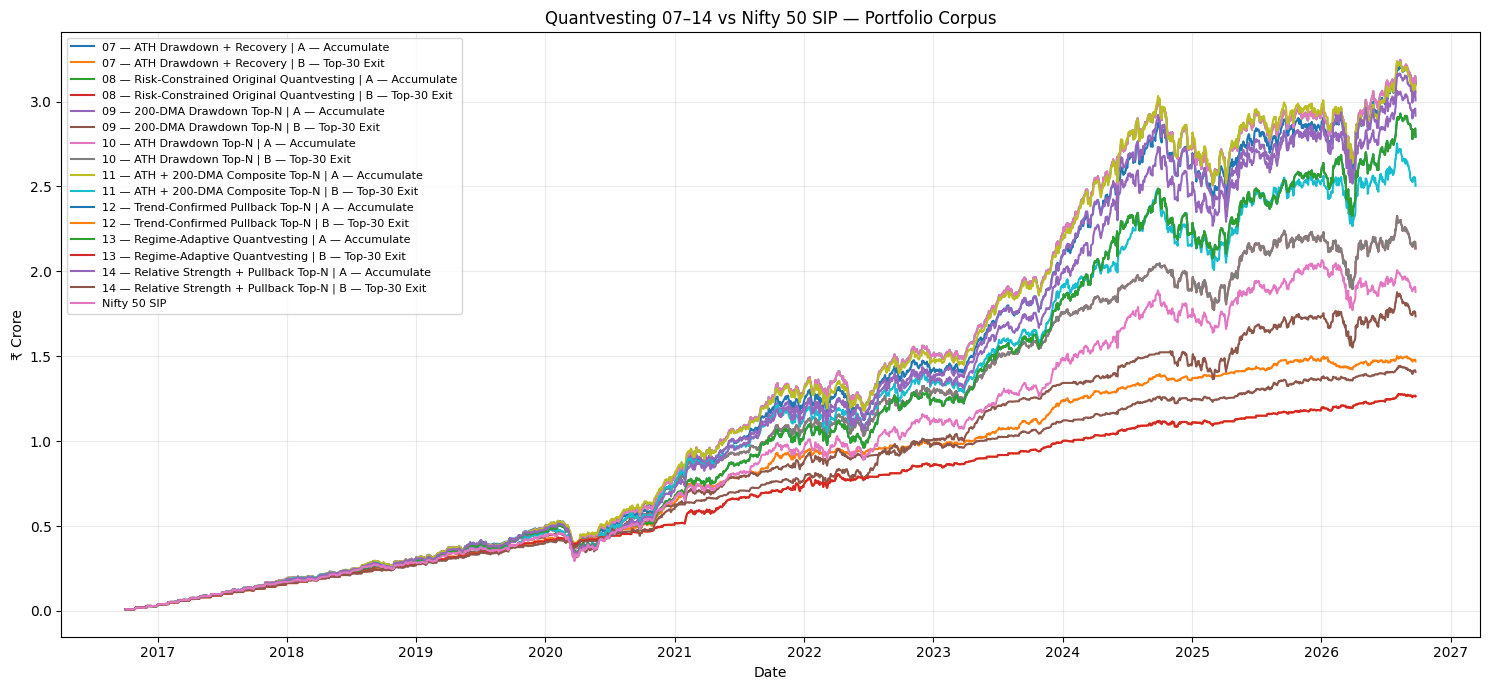

In [17]:
# 17. Corpus comparison chart — A/B variants vs Nifty 50 SIP baseline
plt.figure(figsize=(15,7))
for name,v in results.items(): plt.plot(v["portfolio"].date,v["portfolio"].portfolio_value/1e7,label=name)
plt.title("Quantvesting 07–14 vs Nifty 50 SIP — Portfolio Corpus")
plt.ylabel("₹ Crore");plt.xlabel("Date");plt.grid(alpha=.25);plt.legend(fontsize=8);plt.tight_layout();plt.show()


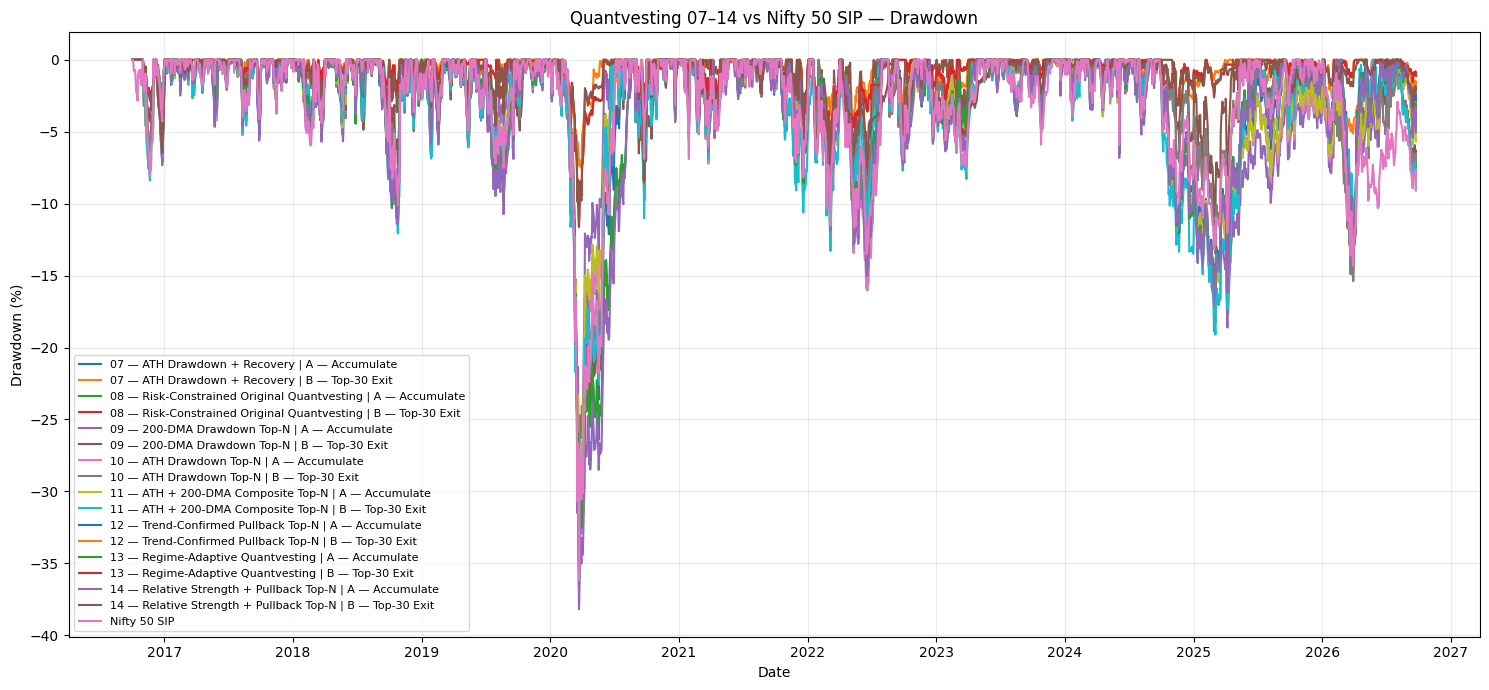

In [18]:
# 18. Drawdown comparison — A/B variants vs Nifty 50 SIP baseline
plt.figure(figsize=(15,7))
for name,v in results.items(): plt.plot(v["portfolio"].date,v["portfolio"].drawdown*100,label=name)
plt.title("Quantvesting 07–14 vs Nifty 50 SIP — Drawdown")
plt.ylabel("Drawdown (%)");plt.xlabel("Date");plt.grid(alpha=.25);plt.legend(fontsize=8);plt.tight_layout();plt.show()


In [19]:
# 18. Annual / calendar-year comparison
calendar_rows=[]
for name,v in results.items():
    p=v["portfolio"].copy();p["year"]=p.date.dt.year
    for year,g in p.groupby("year"):
        if len(g)<20:continue
        calendar_rows.append({"Strategy":name,"Year":year,"Start Corpus":float(g.portfolio_value.iloc[0]),"End Corpus":float(g.portfolio_value.iloc[-1]),"Year Change":float(g.portfolio_value.iloc[-1]/g.portfolio_value.iloc[0]-1),"Worst DD":float(g.drawdown.min())})
calendar_df=pd.DataFrame(calendar_rows)
display(calendar_df.sort_values(["Year","Strategy"]).style.format({"Start Corpus":"₹{:,.0f}","End Corpus":"₹{:,.0f}","Year Change":"{:.2%}","Worst DD":"{:.2%}"}))

,Strategy,Year,Start Corpus,End Corpus,Year Change,Worst DD
0,07 — ATH Drawdown + Recovery | A — Accumulate,2016,"₹100,000","₹284,798",184.80%,-6.77%
11,07 — ATH Drawdown + Recovery | B — Top-30 Exit,2016,"₹100,000","₹284,053",184.05%,-6.77%
22,08 — Risk-Constrained Original Quantvesting | A — Accumulate,2016,"₹100,000","₹283,353",183.35%,-7.47%
33,08 — Risk-Constrained Original Quantvesting | B — Top-30 Exit,2016,"₹100,000","₹283,353",183.35%,-7.47%
44,09 — 200-DMA Drawdown Top-N | A — Accumulate,2016,"₹100,000","₹291,923",191.92%,-4.29%
55,09 — 200-DMA Drawdown Top-N | B — Top-30 Exit,2016,"₹100,000","₹291,533",191.53%,-4.29%
66,10 — ATH Drawdown Top-N | A — Accumulate,2016,"₹100,000","₹283,353",183.35%,-7.47%
77,10 — ATH Drawdown Top-N | B — Top-30 Exit,2016,"₹100,000","₹283,353",183.35%,-7.47%
88,11 — ATH + 200-DMA Composite Top-N | A — Accumulate,2016,"₹100,000","₹284,793",184.79%,-8.37%
99,11 — ATH + 200-DMA Composite Top-N | B — Top-30 Exit,2016,"₹100,000","₹284,793",184.79%,-8.37%


In [20]:
# 19. Regime attribution using the same descriptive Nifty regime classification for every strategy
bench_raw=yf_download(["^NSEI"],period=HISTORY_PERIOD)
def extract_field(raw,field):
    if raw is None or raw.empty:return pd.Series(dtype=float)
    if isinstance(raw.columns,pd.MultiIndex):
        if field not in raw.columns.get_level_values(0):return pd.Series(dtype=float)
        s=raw[field];s=s.iloc[:,0] if isinstance(s,pd.DataFrame) else s
    else:s=raw[field]
    s=pd.to_numeric(s,errors="coerce").dropna();s.index=pd.to_datetime(s.index).tz_localize(None);return s
nclose=extract_field(bench_raw,"Close")
nb=pd.DataFrame({"close":nclose});nb["dma200"]=nb.close.rolling(200,min_periods=200).mean();nb["peak"]=nb.close.cummax();nb["dd"]=nb.close/nb.peak-1;nb["ret6m"]=nb.close.pct_change(126)
def nreg(r):
    if pd.isna(r.ret6m) or pd.isna(r.dma200):return "Insufficient history"
    if r.dd<=-.10 and r.ret6m<0:return "Stress / Bear"
    if r.dd<=-.10:return "Recovery"
    if r.dd>-.03 and r.ret6m>0 and r.close>=r.dma200:return "Expansion / Bull"
    return "Transition / Sideways"
nb["regime"]=nb.apply(nreg,axis=1)
regime_rows=[]
for name,v in results.items():
    q=v["portfolio"].copy();q["regime"]=q.date.map(nb.regime)
    for rg,g in q.groupby("regime"):
        if len(g)<20:continue
        regime_rows.append({"Strategy":name,"Regime":rg,"Observations":len(g),"Mean Daily Corpus Change":float(g.portfolio_value.pct_change().mean()),"Worst Drawdown Within Regime":float(g.drawdown.min()),"End Corpus":float(g.portfolio_value.iloc[-1])})
regime_df=pd.DataFrame(regime_rows)
display(regime_df.sort_values(["Regime","Strategy"]).style.format({"Mean Daily Corpus Change":"{:.3%}","Worst Drawdown Within Regime":"{:.2%}","End Corpus":"₹{:,.0f}"}))

,Strategy,Regime,Observations,Mean Daily Corpus Change,Worst Drawdown Within Regime,End Corpus
0,07 — ATH Drawdown + Recovery | A — Accumulate,Expansion / Bull,1065,0.785%,-4.26%,"₹29,002,002"
4,07 — ATH Drawdown + Recovery | B — Top-30 Exit,Expansion / Bull,1065,0.711%,-4.04%,"₹14,388,272"
8,08 — Risk-Constrained Original Quantvesting | A — Accumulate,Expansion / Bull,1065,0.789%,-4.81%,"₹29,483,477"
12,08 — Risk-Constrained Original Quantvesting | B — Top-30 Exit,Expansion / Bull,1065,0.758%,-4.72%,"₹21,376,110"
16,09 — 200-DMA Drawdown Top-N | A — Accumulate,Expansion / Bull,1065,0.785%,-5.64%,"₹28,003,008"
20,09 — 200-DMA Drawdown Top-N | B — Top-30 Exit,Expansion / Bull,1065,0.738%,-4.87%,"₹17,617,571"
24,10 — ATH Drawdown Top-N | A — Accumulate,Expansion / Bull,1065,0.789%,-4.81%,"₹29,483,477"
28,10 — ATH Drawdown Top-N | B — Top-30 Exit,Expansion / Bull,1065,0.758%,-4.72%,"₹21,376,110"
32,11 — ATH + 200-DMA Composite Top-N | A — Accumulate,Expansion / Bull,1065,0.783%,-4.22%,"₹29,509,285"
36,11 — ATH + 200-DMA Composite Top-N | B — Top-30 Exit,Expansion / Bull,1065,0.771%,-4.46%,"₹25,425,830"


In [21]:
# 20. Capital-utilization and turnover diagnostics
util=metrics[["Average Invested %","Average Cash %","Buy Events","Trim Events","Exit Events","Final Holdings","Transaction Costs","Capital-Gains Tax","STCG Tax","LTCG Tax","STCG Gains","LTCG Gains","Realized Gains"]].copy()
display(util.style.format({"Average Invested %":"{:.1%}","Average Cash %":"{:.1%}","Buy Events":"{:,.0f}","Trim Events":"{:,.0f}","Exit Events":"{:,.0f}","Final Holdings":"{:,.0f}","Transaction Costs":"₹{:,.0f}","Capital-Gains Tax":"₹{:,.0f}","STCG Tax":"₹{:,.0f}","LTCG Tax":"₹{:,.0f}","STCG Gains":"₹{:,.0f}","LTCG Gains":"₹{:,.0f}","Realized Gains":"₹{:,.0f}"}))

,Average Invested %,Average Cash %,Buy Events,Trim Events,Exit Events,Final Holdings,Transaction Costs,Capital-Gains Tax,STCG Tax,LTCG Tax,STCG Gains,LTCG Gains,Realized Gains
Strategy,,,,,,,,,,,,,
07 — ATH Drawdown + Recovery | A — Accumulate,92.2%,7.8%,"2,109",0,0,30,"₹10,383",₹0,₹0,₹0,₹0,₹0,₹0
07 — ATH Drawdown + Recovery | B — Top-30 Exit,36.1%,63.9%,693,0,252,6,"₹184,390","₹1,519,071","₹1,281,115","₹237,957","₹2,680,793","₹1,867,338","₹4,548,131"
08 — Risk-Constrained Original Quantvesting | A — Accumulate,94.2%,5.8%,"5,757",0,0,30,"₹10,378",₹0,₹0,₹0,₹0,₹0,₹0
08 — Risk-Constrained Original Quantvesting | B — Top-30 Exit,80.3%,19.7%,"5,964",0,226,20,"₹229,263","₹2,447,215","₹1,898,823","₹548,392","₹9,486,719","₹4,387,133","₹13,873,851"
09 — 200-DMA Drawdown Top-N | A — Accumulate,93.6%,6.4%,"4,771",1,0,30,"₹11,391","₹38,513",₹0,"₹38,513",₹0,"₹308,103","₹308,103"
09 — 200-DMA Drawdown Top-N | B — Top-30 Exit,63.3%,36.7%,"4,847",0,393,20,"₹341,513","₹2,478,220","₹2,477,769",₹451,"₹11,113,438","₹-615,966","₹10,497,472"
10 — ATH Drawdown Top-N | A — Accumulate,94.2%,5.8%,"5,757",0,0,30,"₹10,378",₹0,₹0,₹0,₹0,₹0,₹0
10 — ATH Drawdown Top-N | B — Top-30 Exit,80.3%,19.7%,"5,964",0,226,20,"₹229,263","₹2,447,215","₹1,898,823","₹548,392","₹9,486,719","₹4,387,133","₹13,873,851"
11 — ATH + 200-DMA Composite Top-N | A — Accumulate,94.2%,5.8%,"6,150",0,0,30,"₹10,378",₹0,₹0,₹0,₹0,₹0,₹0


## 21A. After-tax / all-costs diagnostic

This table separates trading friction from realized capital-gains tax. Taxes are paid from portfolio cash and are therefore already reflected in Ending Corpus and XIRR. The model taxes only positive realized gains, uses FIFO lots, classifies each sold lot as STCG until 12 months and LTCG after 12 months, and uses the requested 20% / 12.5% rates unless configuration changes them.

In [22]:
# 21A. After-tax / all-costs summary
tax_cost_summary=metrics[["Transaction Costs","Capital-Gains Tax","STCG Tax","LTCG Tax","STCG Gains","LTCG Gains","Realized Gains","Ending Corpus","XIRR"]].copy()
tax_cost_summary["Total Friction"]=tax_cost_summary["Transaction Costs"]+tax_cost_summary["Capital-Gains Tax"]
tax_cost_summary["Friction % of Contributions"]=tax_cost_summary["Total Friction"]/metrics["Contributed Capital"]
display(tax_cost_summary.sort_values("XIRR",ascending=False).style.format({"Transaction Costs":"₹{:,.0f}","Capital-Gains Tax":"₹{:,.0f}","STCG Tax":"₹{:,.0f}","LTCG Tax":"₹{:,.0f}","STCG Gains":"₹{:,.0f}","LTCG Gains":"₹{:,.0f}","Realized Gains":"₹{:,.0f}","Total Friction":"₹{:,.0f}","Friction % of Contributions":"{:.2%}","Ending Corpus":"₹{:,.0f}","XIRR":"{:.2%}"}))


,Transaction Costs,Capital-Gains Tax,STCG Tax,LTCG Tax,STCG Gains,LTCG Gains,Realized Gains,Ending Corpus,XIRR,Total Friction,Friction % of Contributions
Strategy,,,,,,,,,,,
08 — Risk-Constrained Original Quantvesting | A — Accumulate,"₹10,378",₹0,₹0,₹0,₹0,₹0,₹0,"₹31,038,486",18.14%,"₹10,378",0.09%
10 — ATH Drawdown Top-N | A — Accumulate,"₹10,378",₹0,₹0,₹0,₹0,₹0,₹0,"₹31,038,486",18.14%,"₹10,378",0.09%
07 — ATH Drawdown + Recovery | A — Accumulate,"₹10,383",₹0,₹0,₹0,₹0,₹0,₹0,"₹30,990,630",18.11%,"₹10,383",0.09%
11 — ATH + 200-DMA Composite Top-N | A — Accumulate,"₹10,378",₹0,₹0,₹0,₹0,₹0,₹0,"₹30,541,137",17.84%,"₹10,378",0.09%
14 — Relative Strength + Pullback Top-N | A — Accumulate,"₹10,409",₹0,₹0,₹0,₹0,₹0,₹0,"₹30,063,996",17.55%,"₹10,409",0.09%
09 — 200-DMA Drawdown Top-N | A — Accumulate,"₹11,391","₹38,513",₹0,"₹38,513",₹0,"₹308,103","₹308,103","₹29,170,402",16.99%,"₹49,904",0.42%
12 — Trend-Confirmed Pullback Top-N | A — Accumulate,"₹10,528",₹0,₹0,₹0,₹0,₹0,₹0,"₹27,926,055",16.17%,"₹10,528",0.09%
13 — Regime-Adaptive Quantvesting | A — Accumulate,"₹10,528",₹0,₹0,₹0,₹0,₹0,₹0,"₹27,926,055",16.17%,"₹10,528",0.09%
11 — ATH + 200-DMA Composite Top-N | B — Top-30 Exit,"₹255,977","₹3,297,426","₹2,628,960","₹668,466","₹12,778,209","₹5,114,232","₹17,892,441","₹25,034,577",14.13%,"₹3,553,403",29.61%


In [23]:
# 21. Trade-ledger concentration diagnostics — descriptive, not a score
rows=[]
for name,v in results.items():
    t=v["trades"]
    if t.empty or "symbol" not in t.columns:continue
    buys=t[t.event.astype(str).str.contains("BUY|ENTRY",regex=True)].copy()
    if buys.empty:continue
    by=buys.groupby("symbol").notional.sum().sort_values(ascending=False);tot=by.sum()
    rows.append({"Strategy":name,"Top-1 cumulative purchase share":by.head(1).sum()/tot if tot else np.nan,"Top-3":by.head(3).sum()/tot if tot else np.nan,"Top-5":by.head(5).sum()/tot if tot else np.nan,"Top-10":by.head(10).sum()/tot if tot else np.nan,"Distinct purchased stocks":by.size})
conc=pd.DataFrame(rows).set_index("Strategy")
display(conc.style.format({c:"{:.1%}" for c in conc.columns if c.startswith("Top-")}))

,Top-1 cumulative purchase share,Top-3,Top-5,Top-10,Distinct purchased stocks
Strategy,,,,,
07 — ATH Drawdown + Recovery | A — Accumulate,9.4%,24.0%,34.8%,58.7%,30
07 — ATH Drawdown + Recovery | B — Top-30 Exit,5.9%,16.4%,25.2%,43.7%,51
08 — Risk-Constrained Original Quantvesting | A — Accumulate,9.4%,23.5%,35.1%,58.8%,30
08 — Risk-Constrained Original Quantvesting | B — Top-30 Exit,4.9%,13.8%,21.7%,39.9%,52
09 — 200-DMA Drawdown Top-N | A — Accumulate,7.0%,20.1%,30.5%,51.9%,30
09 — 200-DMA Drawdown Top-N | B — Top-30 Exit,3.5%,10.1%,16.4%,30.1%,51
10 — ATH Drawdown Top-N | A — Accumulate,9.4%,23.5%,35.1%,58.8%,30
10 — ATH Drawdown Top-N | B — Top-30 Exit,4.9%,13.8%,21.7%,39.9%,52
11 — ATH + 200-DMA Composite Top-N | A — Accumulate,6.3%,18.1%,27.8%,49.5%,30


In [24]:
# 22. Strategy-specific opportunity histories — Top 20 purchase set and Top 30 exit set
opportunity_history={}
for base in STRATEGIES:
    for limit,label_suffix in [(TOP_N,"A/B purchase Top-20"),(TOP_EXIT_N,"B exit Top-30")]:
        rows=[]
        for date in sip_dates:
            prev=market_days[market_days<date]
            if len(prev)==0:continue
            sd=pd.Timestamp(prev[-1]); opp=candidates_on_date(sd,base,limit=limit)
            for rank,r in opp.reset_index(drop=True).iterrows():
                rows.append({"strategy":base,"screen":label_suffix,"signal_date":sd,"rank":rank+1,"symbol":r.symbol,"conviction":r.conviction,"category":r.category,"Close":r.Close,"ath_gap":r.ath_gap,"dma_gap":r.dma_gap,"pullback":r.pullback,"rs_6m":r.rs_6m,"rs_12m":r.rs_12m,"composite_score":r.get("composite_score",np.nan),"market_regime":r.get("market_regime",np.nan)})
        opportunity_history[f"{base} | {label_suffix}"]=pd.DataFrame(rows)
print({k:len(v) for k,v in opportunity_history.items()})


{'07 — ATH Drawdown + Recovery | A/B purchase Top-20': 845, '07 — ATH Drawdown + Recovery | B exit Top-30': 845, '08 — Risk-Constrained Original Quantvesting | A/B purchase Top-20': 2008, '08 — Risk-Constrained Original Quantvesting | B exit Top-30': 2276, '09 — 200-DMA Drawdown Top-N | A/B purchase Top-20': 1580, '09 — 200-DMA Drawdown Top-N | B exit Top-30': 1799, '10 — ATH Drawdown Top-N | A/B purchase Top-20': 2008, '10 — ATH Drawdown Top-N | B exit Top-30': 2276, '11 — ATH + 200-DMA Composite Top-N | A/B purchase Top-20': 2380, '11 — ATH + 200-DMA Composite Top-N | B exit Top-30': 3570, '12 — Trend-Confirmed Pullback Top-N | A/B purchase Top-20': 546, '12 — Trend-Confirmed Pullback Top-N | B exit Top-30': 546, '13 — Regime-Adaptive Quantvesting | A/B purchase Top-20': 546, '13 — Regime-Adaptive Quantvesting | B exit Top-30': 546, '14 — Relative Strength + Pullback Top-N | A/B purchase Top-20': 903, '14 — Relative Strength + Pullback Top-N | B exit Top-30': 903}


In [25]:
# 25. Common implementation audit

audit_rows=[]
for name,v in results.items():
    p=v["portfolio"];t=v["trades"]
    if name==NIFTY_BENCHMARK_NAME:
        audit_rows.append({"Strategy":name,"Integer buys":"N/A — fractional index units","Integer sells":"N/A","Purchase cap":"N/A — index benchmark","Sector cap":"N/A — index benchmark","No negative cash":bool((p.cash>=-1e-8).all()),"Holding limit":"N/A — index benchmark"})
        continue
    buys=t[t.event.astype(str).str.contains("BUY|ENTRY",regex=True)] if not t.empty else pd.DataFrame()
    sales=t[t.event.astype(str).str.contains("TRIM|EXIT",regex=True)] if not t.empty else pd.DataFrame()
    integer_buy=bool(np.all(np.isclose(buys.shares,np.round(buys.shares)))) if not buys.empty else True
    integer_sell=bool(np.all(np.isclose(sales.shares,np.round(sales.shares)))) if not sales.empty else True
    position_ok=bool((buys.position_pct_after<=MAX_POSITION_PCT+1e-9).all()) if not buys.empty and "position_pct_after" in buys else True
    sector_ok=bool((buys.sector_pct_after<=MAX_SECTOR_PCT+1e-9).all()) if not buys.empty and "sector_pct_after" in buys else True
    cash_ok=bool((p.cash>=-1e-8).all())
    holdings_ok=bool((p.open_positions<=MAX_HOLDINGS).all())
    audit_rows.append({"Strategy":name,"Integer buys":integer_buy,"Integer sells":integer_sell,"Purchase cap":position_ok,"Sector cap":sector_ok,"No negative cash":cash_ok,"Holding limit":holdings_ok})
audit_df=pd.DataFrame(audit_rows).set_index("Strategy")
display(audit_df)


,Integer buys,Integer sells,Purchase cap,Sector cap,No negative cash,Holding limit
Strategy,,,,,,
07 — ATH Drawdown + Recovery | A — Accumulate,True,True,True,True,True,True
07 — ATH Drawdown + Recovery | B — Top-30 Exit,True,True,True,True,True,True
08 — Risk-Constrained Original Quantvesting | A — Accumulate,True,True,True,True,True,True
08 — Risk-Constrained Original Quantvesting | B — Top-30 Exit,True,True,True,True,True,True
09 — 200-DMA Drawdown Top-N | A — Accumulate,True,True,True,True,True,True
09 — 200-DMA Drawdown Top-N | B — Top-30 Exit,True,True,True,True,True,True
10 — ATH Drawdown Top-N | A — Accumulate,True,True,True,True,True,True
10 — ATH Drawdown Top-N | B — Top-30 Exit,True,True,True,True,True,True
11 — ATH + 200-DMA Composite Top-N | A — Accumulate,True,True,True,True,True,True


In [26]:
# 24. Export a directly comparable CSV pack for every strategy
OUTPUT_ROOT=Path("quantvesting_07_to_14_top20_top30_comparison_outputs");OUTPUT_ROOT.mkdir(exist_ok=True)
def slug(s):return re.sub(r"[^A-Za-z0-9]+","_",s).strip("_").lower()
manifest=[]
for name,v in results.items():
    folder=OUTPUT_ROOT/slug(name);folder.mkdir(exist_ok=True)
    p=v["portfolio"].copy();t=v["trades"].copy()
    p.to_csv(folder/"01_daily_portfolio.csv",index=False);p[p.date.isin(sip_dates)].to_csv(folder/"02_monthly_journey.csv",index=False)
    t.to_csv(folder/"03_trade_ledger.csv",index=False)
    for k,odf in opportunity_history.items():
        if k.startswith(v.get("base_strategy",name)+" | "):
            suffix=slug(k.split(" | ",1)[1]); odf.to_csv(folder/f"04_opportunity_history_{suffix}.csv",index=False)
    v["contributions"].to_csv(folder/"05_contributions.csv",index=False)
    pd.DataFrame([metrics.loc[name].to_dict()|{"Strategy":name}]).to_csv(folder/"06_strategy_summary.csv",index=False)
    manifest.append({"Strategy":name,"Output folder":str(folder)})
manifest_df=pd.DataFrame(manifest);manifest_df.to_csv(OUTPUT_ROOT/"00_manifest.csv",index=False)
display(manifest_df.style.hide(axis="index"))
print(f"✓ Export pack: {OUTPUT_ROOT.resolve()}")

Strategy,Output folder
07 — ATH Drawdown + Recovery | A — Accumulate,quantvesting_07_to_14_top20_top30_comparison_outputs/07_ath_drawdown_recovery_a_accumulate
07 — ATH Drawdown + Recovery | B — Top-30 Exit,quantvesting_07_to_14_top20_top30_comparison_outputs/07_ath_drawdown_recovery_b_top_30_exit
08 — Risk-Constrained Original Quantvesting | A — Accumulate,quantvesting_07_to_14_top20_top30_comparison_outputs/08_risk_constrained_original_quantvesting_a_accumulate
08 — Risk-Constrained Original Quantvesting | B — Top-30 Exit,quantvesting_07_to_14_top20_top30_comparison_outputs/08_risk_constrained_original_quantvesting_b_top_30_exit
09 — 200-DMA Drawdown Top-N | A — Accumulate,quantvesting_07_to_14_top20_top30_comparison_outputs/09_200_dma_drawdown_top_n_a_accumulate
09 — 200-DMA Drawdown Top-N | B — Top-30 Exit,quantvesting_07_to_14_top20_top30_comparison_outputs/09_200_dma_drawdown_top_n_b_top_30_exit
10 — ATH Drawdown Top-N | A — Accumulate,quantvesting_07_to_14_top20_top30_comparison_outputs/10_ath_drawdown_top_n_a_accumulate
10 — ATH Drawdown Top-N | B — Top-30 Exit,quantvesting_07_to_14_top20_top30_comparison_outputs/10_ath_drawdown_top_n_b_top_30_exit
11 — ATH + 200-DMA Composite Top-N | A — Accumulate,quantvesting_07_to_14_top20_top30_comparison_outputs/11_ath_200_dma_composite_top_n_a_accumulate
11 — ATH + 200-DMA Composite Top-N | B — Top-30 Exit,quantvesting_07_to_14_top20_top30_comparison_outputs/11_ath_200_dma_composite_top_n_b_top_30_exit


✓ Export pack: /content/quantvesting_07_to_14_top20_top30_comparison_outputs


In [27]:
# 26. FINAL COMPARISON SUMMARY — sorted descending by XIRR

final_summary=metrics[["Ending Corpus","Profit","XIRR","Max Drawdown","Average Invested %","Average Cash %","Final Cash","Final Holdings","Buy Events","Trim Events","Exit Events","Contributed Capital","Transaction Costs","Capital-Gains Tax","Realized Gains"]].copy()
final_summary["Profit % of Contributions"]=final_summary.Profit/final_summary["Contributed Capital"]
final_summary=final_summary.sort_values("XIRR",ascending=False)
final_summary.insert(0,"XIRR Rank",range(1,len(final_summary)+1))
print("="*110)
print("QUANTVESTING 07–14 + NIFTY 50 SIP — FINAL APPLES-TO-APPLES COMPARISON")
print("Sorted descending by XIRR")
print("="*110)
display(final_summary.style.format({"XIRR Rank":"{:,.0f}","Ending Corpus":"₹{:,.0f}","Profit":"₹{:,.0f}","XIRR":"{:.2%}","Max Drawdown":"{:.2%}","Average Invested %":"{:.1%}","Average Cash %":"{:.1%}","Final Cash":"₹{:,.0f}","Final Holdings":"{:,.0f}","Buy Events":"{:,.0f}","Trim Events":"{:,.0f}","Exit Events":"{:,.0f}","Contributed Capital":"₹{:,.0f}","Transaction Costs":"₹{:,.0f}","Capital-Gains Tax":"₹{:,.0f}","Realized Gains":"₹{:,.0f}","Profit % of Contributions":"{:.1%}"}))


QUANTVESTING 07–14 + NIFTY 50 SIP — FINAL APPLES-TO-APPLES COMPARISON
Sorted descending by XIRR


,XIRR Rank,Ending Corpus,Profit,XIRR,Max Drawdown,Average Invested %,Average Cash %,Final Cash,Final Holdings,Buy Events,Trim Events,Exit Events,Contributed Capital,Transaction Costs,Capital-Gains Tax,Realized Gains,Profit % of Contributions
Strategy,,,,,,,,,,,,,,,,,
08 — Risk-Constrained Original Quantvesting | A — Accumulate,1,"₹31,038,486","₹19,038,486",18.14%,-33.14%,94.2%,5.8%,"₹1,611,167",30,"5,757",0,0,"₹12,000,000","₹10,378",₹0,₹0,158.7%
10 — ATH Drawdown Top-N | A — Accumulate,2,"₹31,038,486","₹19,038,486",18.14%,-33.14%,94.2%,5.8%,"₹1,611,167",30,"5,757",0,0,"₹12,000,000","₹10,378",₹0,₹0,158.7%
07 — ATH Drawdown + Recovery | A — Accumulate,3,"₹30,990,630","₹18,990,630",18.11%,-34.02%,92.2%,7.8%,"₹1,606,526",30,"2,109",0,0,"₹12,000,000","₹10,383",₹0,₹0,158.3%
11 — ATH + 200-DMA Composite Top-N | A — Accumulate,4,"₹30,541,137","₹18,541,137",17.84%,-32.18%,94.2%,5.8%,"₹1,611,167",30,"6,150",0,0,"₹12,000,000","₹10,378",₹0,₹0,154.5%
14 — Relative Strength + Pullback Top-N | A — Accumulate,5,"₹30,063,996","₹18,063,996",17.55%,-38.19%,92.2%,7.8%,"₹1,580,670",30,"2,322",0,0,"₹12,000,000","₹10,409",₹0,₹0,150.5%
09 — 200-DMA Drawdown Top-N | A — Accumulate,6,"₹29,170,402","₹17,170,402",16.99%,-29.73%,93.6%,6.4%,"₹1,527,795",30,"4,771",1,0,"₹12,000,000","₹11,391","₹38,513","₹308,103",143.1%
12 — Trend-Confirmed Pullback Top-N | A — Accumulate,7,"₹27,926,055","₹15,926,055",16.17%,-36.63%,89.2%,10.8%,"₹1,461,109",30,"1,323",0,0,"₹12,000,000","₹10,528",₹0,₹0,132.7%
13 — Regime-Adaptive Quantvesting | A — Accumulate,8,"₹27,926,055","₹15,926,055",16.17%,-36.63%,89.2%,10.8%,"₹1,461,109",30,"1,323",0,0,"₹12,000,000","₹10,528",₹0,₹0,132.7%
11 — ATH + 200-DMA Composite Top-N | B — Top-30 Exit,9,"₹25,034,577","₹13,034,577",14.13%,-35.23%,94.2%,5.8%,"₹1,331,711",25,"10,488",0,277,"₹12,000,000","₹255,977","₹3,297,426","₹17,892,441",108.6%


## Interpretation discipline

This notebook compares the finalized Quantvesting strategies **07–14** against a passive **Nifty 50 SIP price-index baseline** using the same ₹100,000 monthly contribution schedule and journey dates. The final comparison table is explicitly sorted **descending by XIRR**.

Important benchmark convention: the Nifty 50 baseline uses the **Nifty 50 Price Index (`^NSEI`)** with fractional index units and therefore does not impose the stock-level 5% purchase cap, 20% sector cap, 30-stock limit, or integer-share constraint. It is a passive index baseline rather than an ETF execution simulation. NSE Indices distinguishes the Nifty 50 Price Index from the Nifty 50 Total Returns (TR) index; the price index excludes dividends, while the TR index incorporates dividends. For a fully investable passive benchmark, a future version can add Nifty 50 TRI / ETF tracking separately.

Do not optimize parameters from the resulting performance. Use the outputs to compare ending corpus, XIRR, drawdown path, capital utilization, turnover, concentration, calendar periods and market regimes. The benchmark is included to answer the central research question: **does a Quantvesting strategy add value over a simple Nifty 50 SIP under the same contribution journey?**

The **08 Original Quantvesting** strategy remains structurally different because it has a daily frozen-ATH exit mechanism; its turnover and cash redeployment should therefore be interpreted separately from the no-routine-sell strategies.


### After-tax / all-costs convention
For stock strategies, BUY, TRIM and SELL/EXIT transaction costs are charged to portfolio cash. Realized profitable sales also pay modeled capital-gains tax from portfolio cash using FIFO lot accounting and the configured 12-month STCG/LTCG boundary. The requested base case is 20% STCG and 12.5% LTCG. Cess, surcharge, the statutory annual LTCG exemption and capital-loss set-off are not modeled in this simplified research version; this keeps the calculation aligned with the user-specified headline rates. Those statutory details can be added as a separate tax-realism sensitivity later. The Nifty 50 price-index baseline remains a theoretical index-unit benchmark and therefore has no modeled stock trading costs or realized capital-gains taxes.
